# Regime-Switching Time Series Analysis
## Step 2: Visualisation and Regime-Switching Model Estimation

This notebook implements Step 2 of the regime-switching analysis project, focusing on:

### Part A: Visualisation and Regime Identification
- Comprehensive visualisations of financial time series
- Identification of regime changes during the COVID-19 period
- Selection of primary series for detailed modelling

### Part B: Markov Regime-Switching Model Estimation
- Models with different numbers of states (2, 3, 4)
- Different μ with constant σ specifications
- Different σ with constant μ specifications
- Full switching models (different μ and σ)

The analysis follows British English conventions without contractions throughout.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import our custom modules
from visualization import (create_regime_plots, calculate_regime_statistics, 
                          identify_structural_breaks, create_comparative_regime_plot,
                          generate_regime_summary_report)
from regime_models import MarkovRegimeSwitching, compare_models

# Set plotting style for British academic standards
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Configure pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

### Data Loading and Preparation

We begin by loading the financial time series data collected in Step 1 and preparing it for regime analysis.

In [2]:
# Load the financial time series data
try:
    data = pd.read_csv('financial_time_series_2019_2022.csv', index_col=0, parse_dates=True)
    print('Data loaded successfully from financial_time_series_2019_2022.csv')
except FileNotFoundError:
    print('Data file not found. Please run Step 1 (Data Collection) first.')
    # For demonstration, create sample data
    print('Creating sample data for demonstration...')
    dates = pd.date_range('2019-01-01', '2022-09-30', freq='B')
    np.random.seed(42)
    data = pd.DataFrame({
        'SP500_Returns': np.random.normal(0.05, 1.2, len(dates)),
        'Bitcoin_Returns': np.random.normal(0.1, 3.5, len(dates)),
        'VIX': np.random.gamma(2, 10, len(dates)),
        'US10Y': np.random.normal(2.0, 0.8, len(dates))
    }, index=dates)

print(f'\nData shape: {data.shape}')
print(f'Date range: {data.index.min()} to {data.index.max()}')
print(f'Available series: {list(data.columns)}')

# Display basic statistics
print('\nBasic Statistics:')
data.describe().round(4)

Data loaded successfully from financial_time_series_2019_2022.csv

Data shape: (943, 7)
Date range: 2019-01-03 00:00:00 to 2022-09-29 00:00:00
Available series: ['SP500_Returns', 'Bitcoin_Returns', 'Gold_Returns', 'Oil_Returns', 'US10Y', 'VIX', 'BAA_Spread']

Basic Statistics:


,SP500_Returns,Bitcoin_Returns,Gold_Returns,Oil_Returns,US10Y,VIX,BAA_Spread
count,943.0000,943.0000,943.0000,943.0000,943.0000,943.0000,943.0000
mean,0.0498,0.2321,0.0326,-0.2663,1.7175,22.2998,2.2506
std,1.4348,4.1465,1.0211,11.4247,0.7605,8.9243,0.3669
min,-11.9841,-37.1695,-4.9787,-305.9661,0.4990,11.5400,1.7200
25%,-0.4824,-1.7010,-0.4223,-1.2150,1.1385,16.2650,2.0055
50%,0.1072,0.1245,0.0658,0.2479,1.6250,20.6700,2.1891
75%,0.7242,2.1737,0.5660,1.6230,2.2095,26.1900,2.2950
max,9.3828,18.7465,5.9477,37.6623,3.9640,82.6900,3.4700


## Part A: Visualisation and Regime Identification

### Comprehensive Time Series Visualisation

We create detailed visualisations to identify potential regime changes across different asset classes. The analysis focuses on the period spanning pre-COVID (2019), the pandemic crisis (2020), recovery phase (2021), and post-pandemic inflation period (2022).

COMPARATIVE REGIME ANALYSIS ACROSS ASSET CLASSES
Analysing series: ['SP500_Returns', 'Bitcoin_Returns', 'US10Y', 'VIX']
Comparative plot saved as: comparative_regime_analysis.png


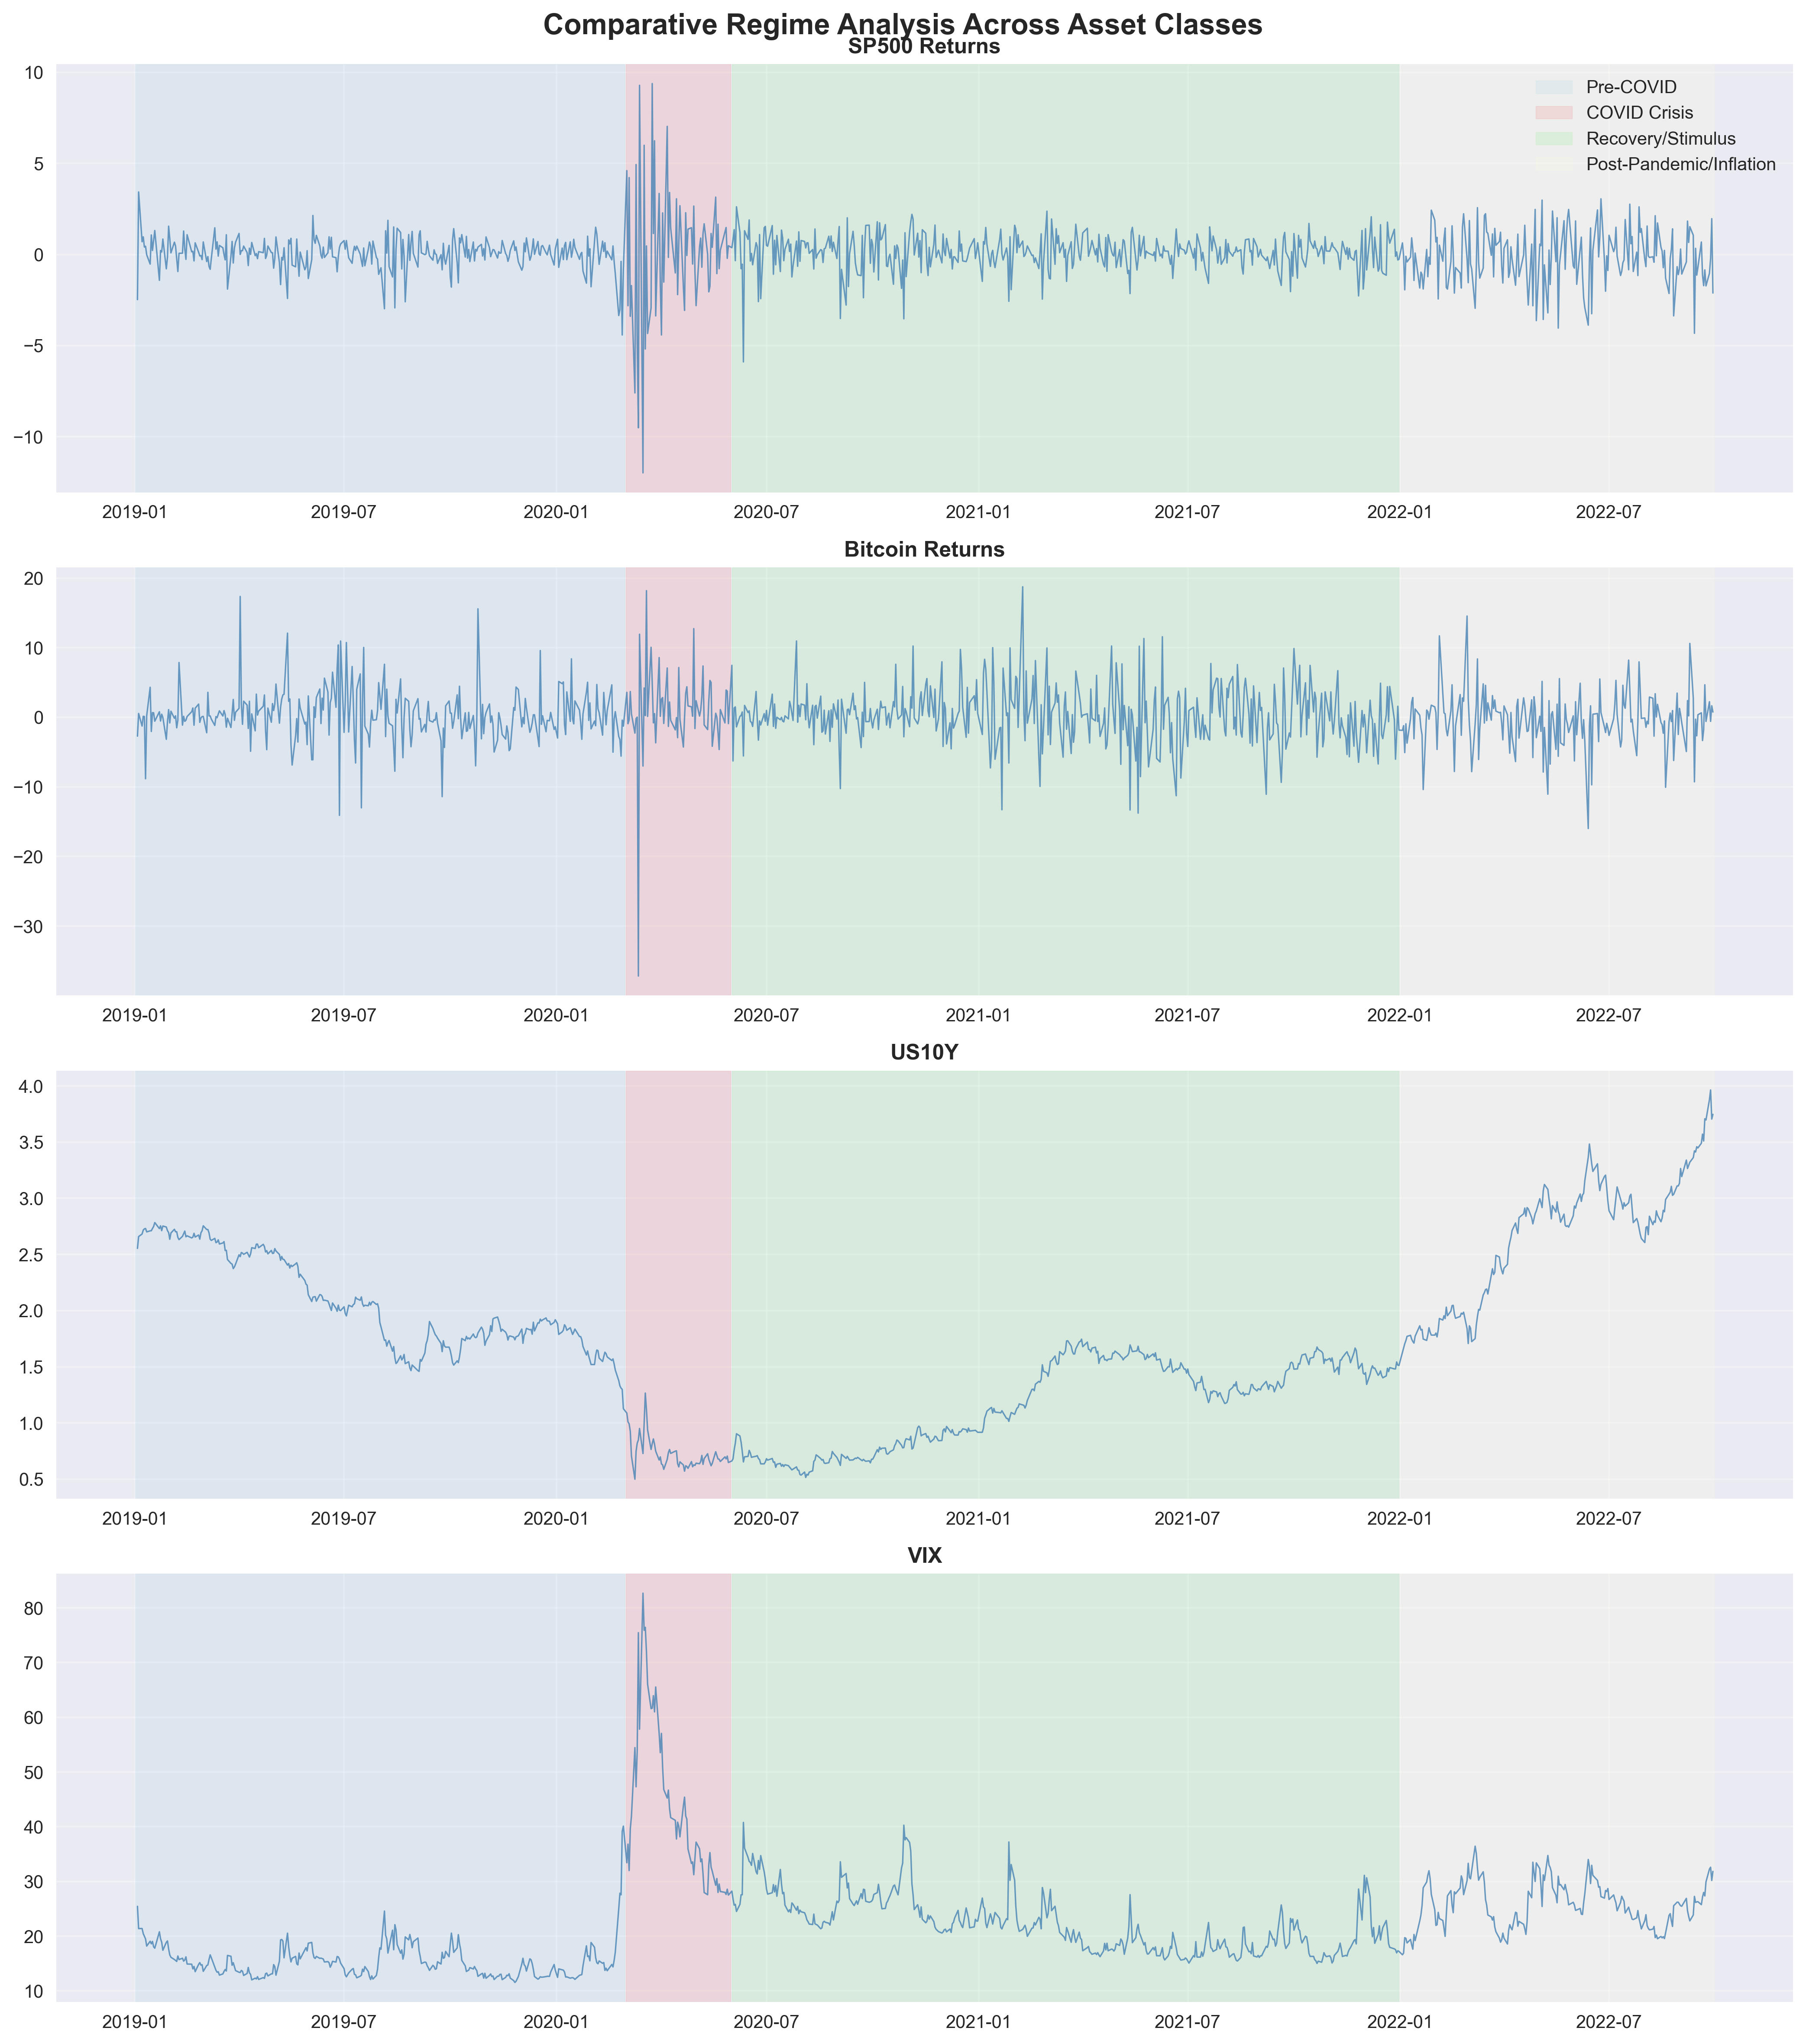


Comparative analysis completed. Plot saved as: comparative_regime_analysis.png


In [3]:
# Create comparative regime analysis across all series
print('COMPARATIVE REGIME ANALYSIS ACROSS ASSET CLASSES')
print('=' * 60)

# Select series for comparative analysis
available_series = [col for col in data.columns if col in ['SP500_Returns', 'Bitcoin_Returns', 'VIX', 'US10Y']]

print(f'Analysing series: {available_series}')

# Create comparative plots
comparative_stats = create_comparative_regime_plot(data, available_series, save_plot=True)

print('\nComparative analysis completed. Plot saved as: comparative_regime_analysis.png')

DETAILED REGIME ANALYSIS FOR INDIVIDUAL SERIES

Analysing: SP500_Returns
----------------------------------------
Plot saved as: regime_analysis_sp500_returns.png


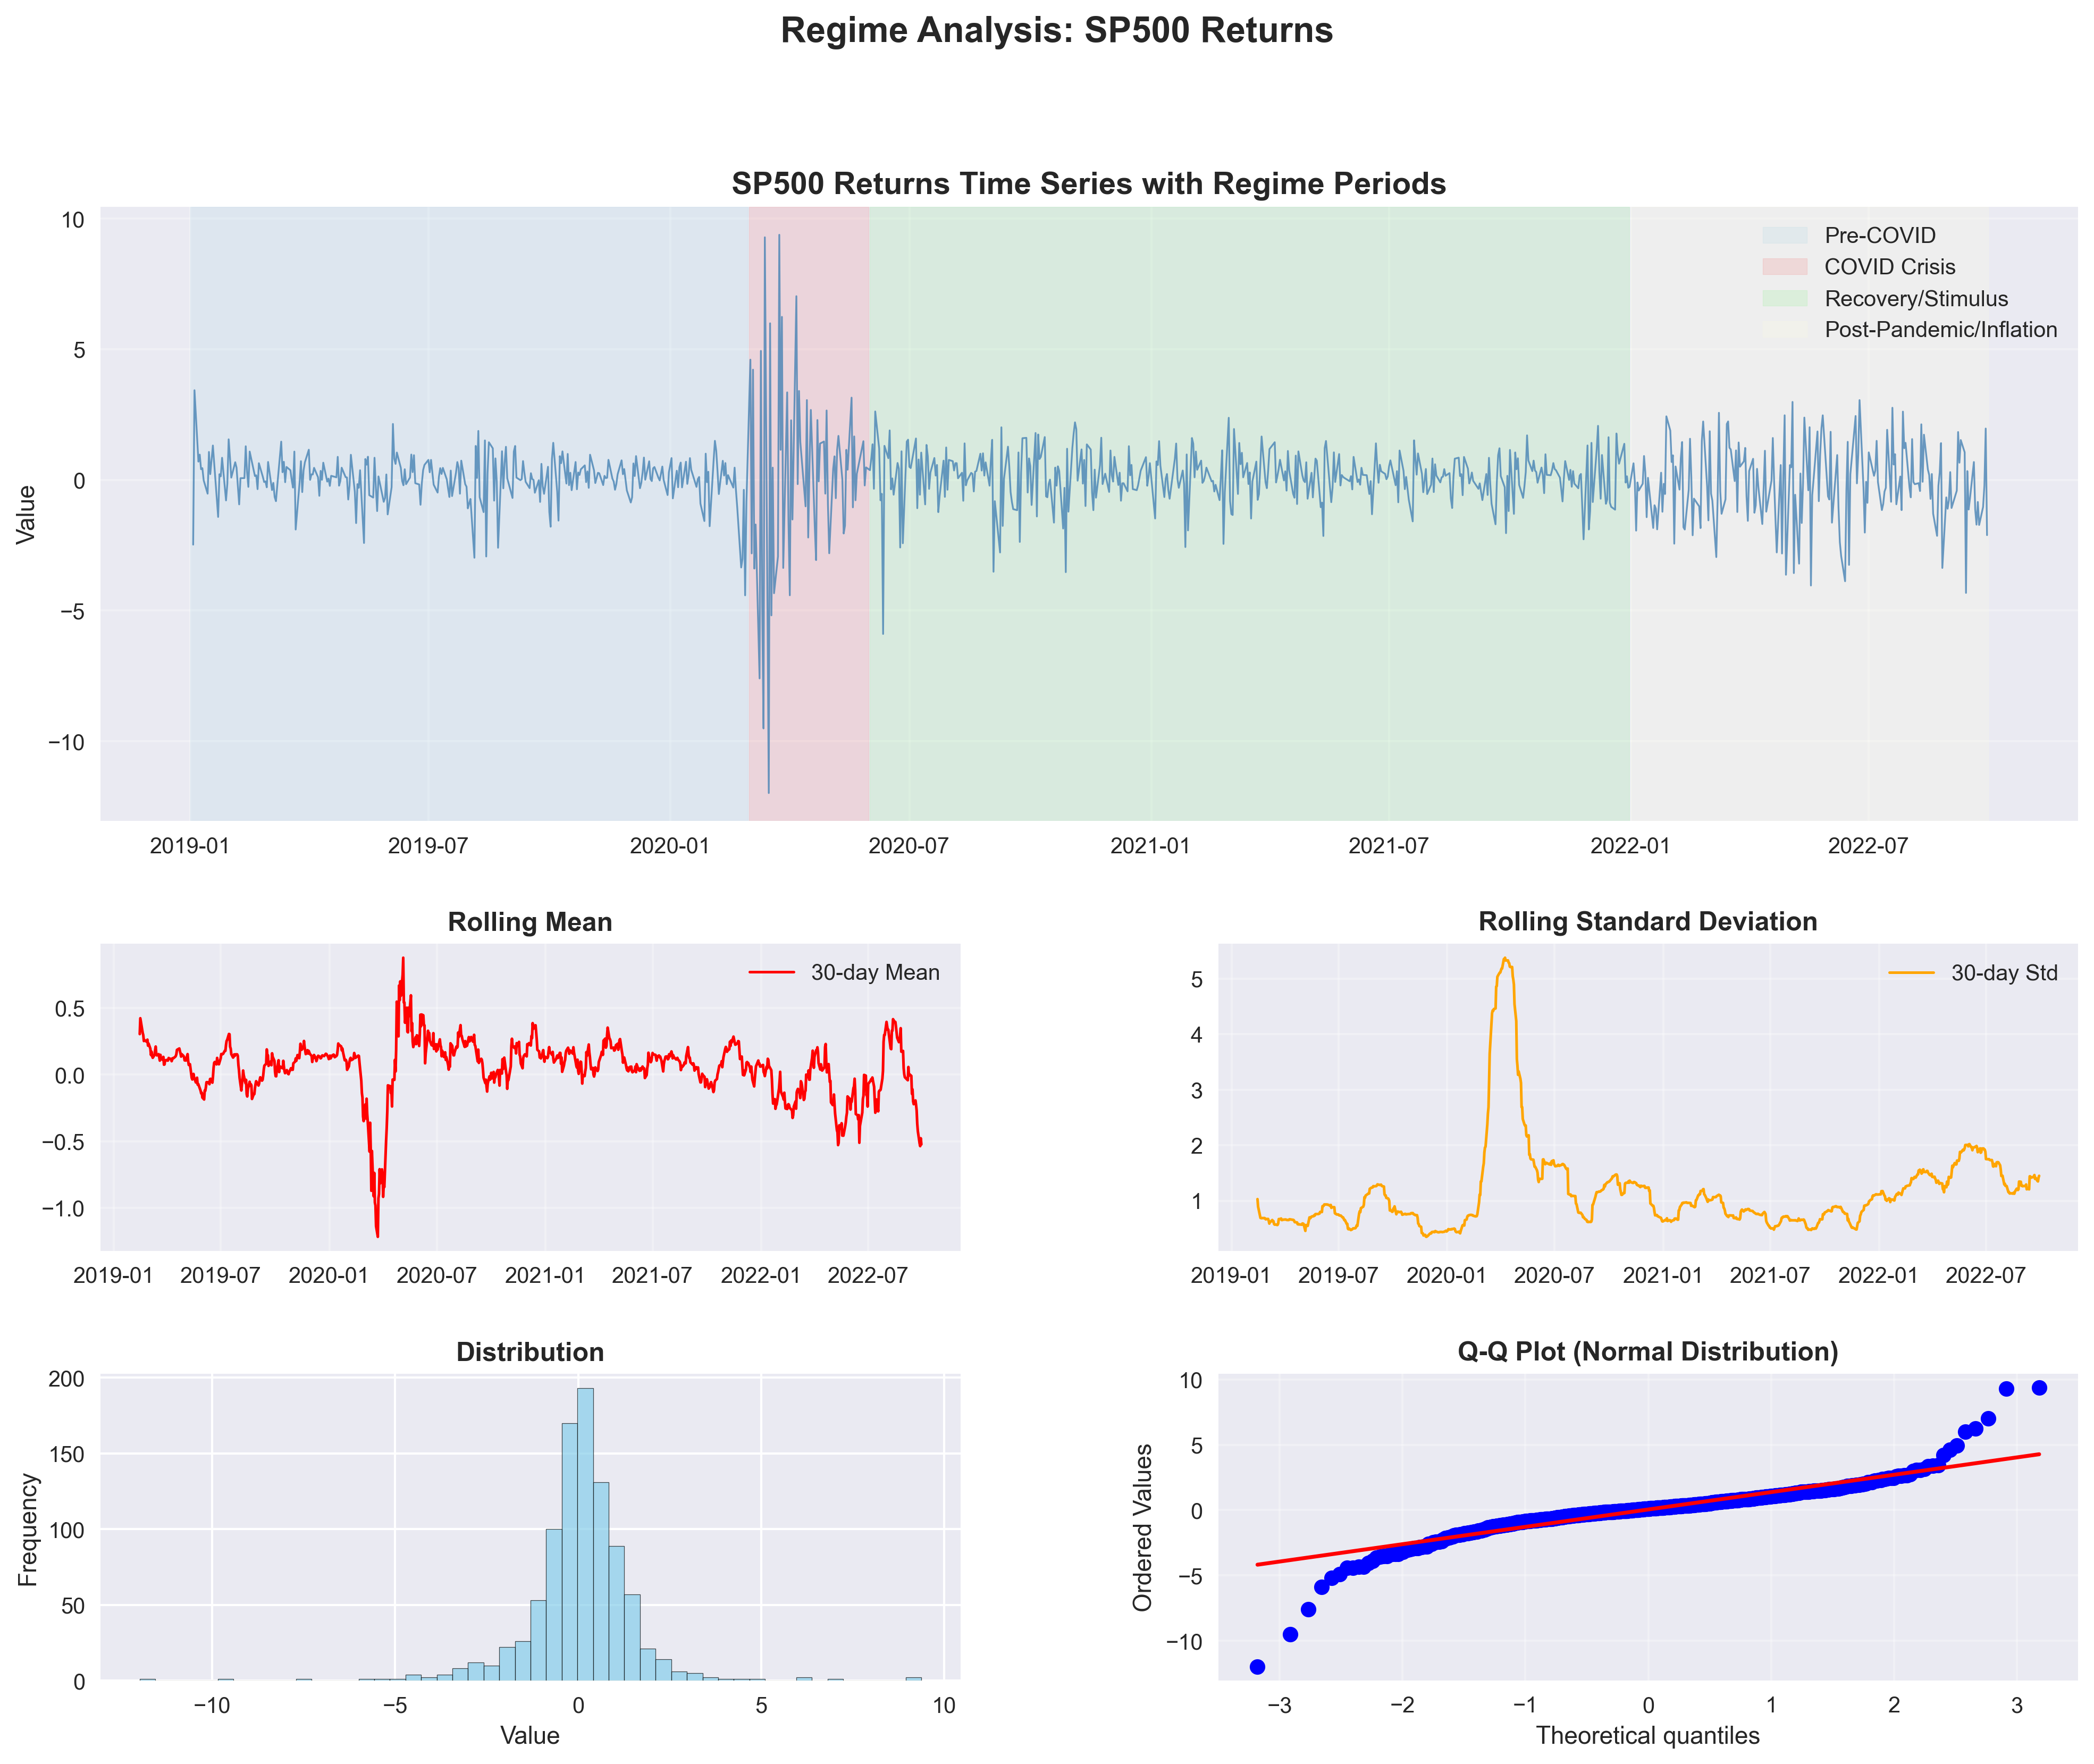


Regime Statistics:
                         Count    Mean     Std      Min     Max  Skewness  \
Pre-COVID                291.0  0.0597  0.8621  -4.4163  3.4336   -1.1693   
COVID Crisis              63.0  0.1209  3.8403 -11.9841  9.3828   -0.3066   
Recovery/Stimulus        402.0  0.1163  0.9746  -5.8944  2.6212   -1.0303   
Post-Pandemic/Inflation  187.0 -0.1327  1.5028  -4.3237  3.0563   -0.2494   

                         Kurtosis  Jarque_Bera_Stat  Jarque_Bera_Pvalue  
Pre-COVID                  4.8571          339.6029              0.0000  
COVID Crisis               1.5607            5.6946              0.0580  
Recovery/Stimulus          4.1062          344.0287              0.0000  
Post-Pandemic/Inflation   -0.0283            1.9356              0.3799  

Analysing: Bitcoin_Returns
----------------------------------------
Plot saved as: regime_analysis_bitcoin_returns.png


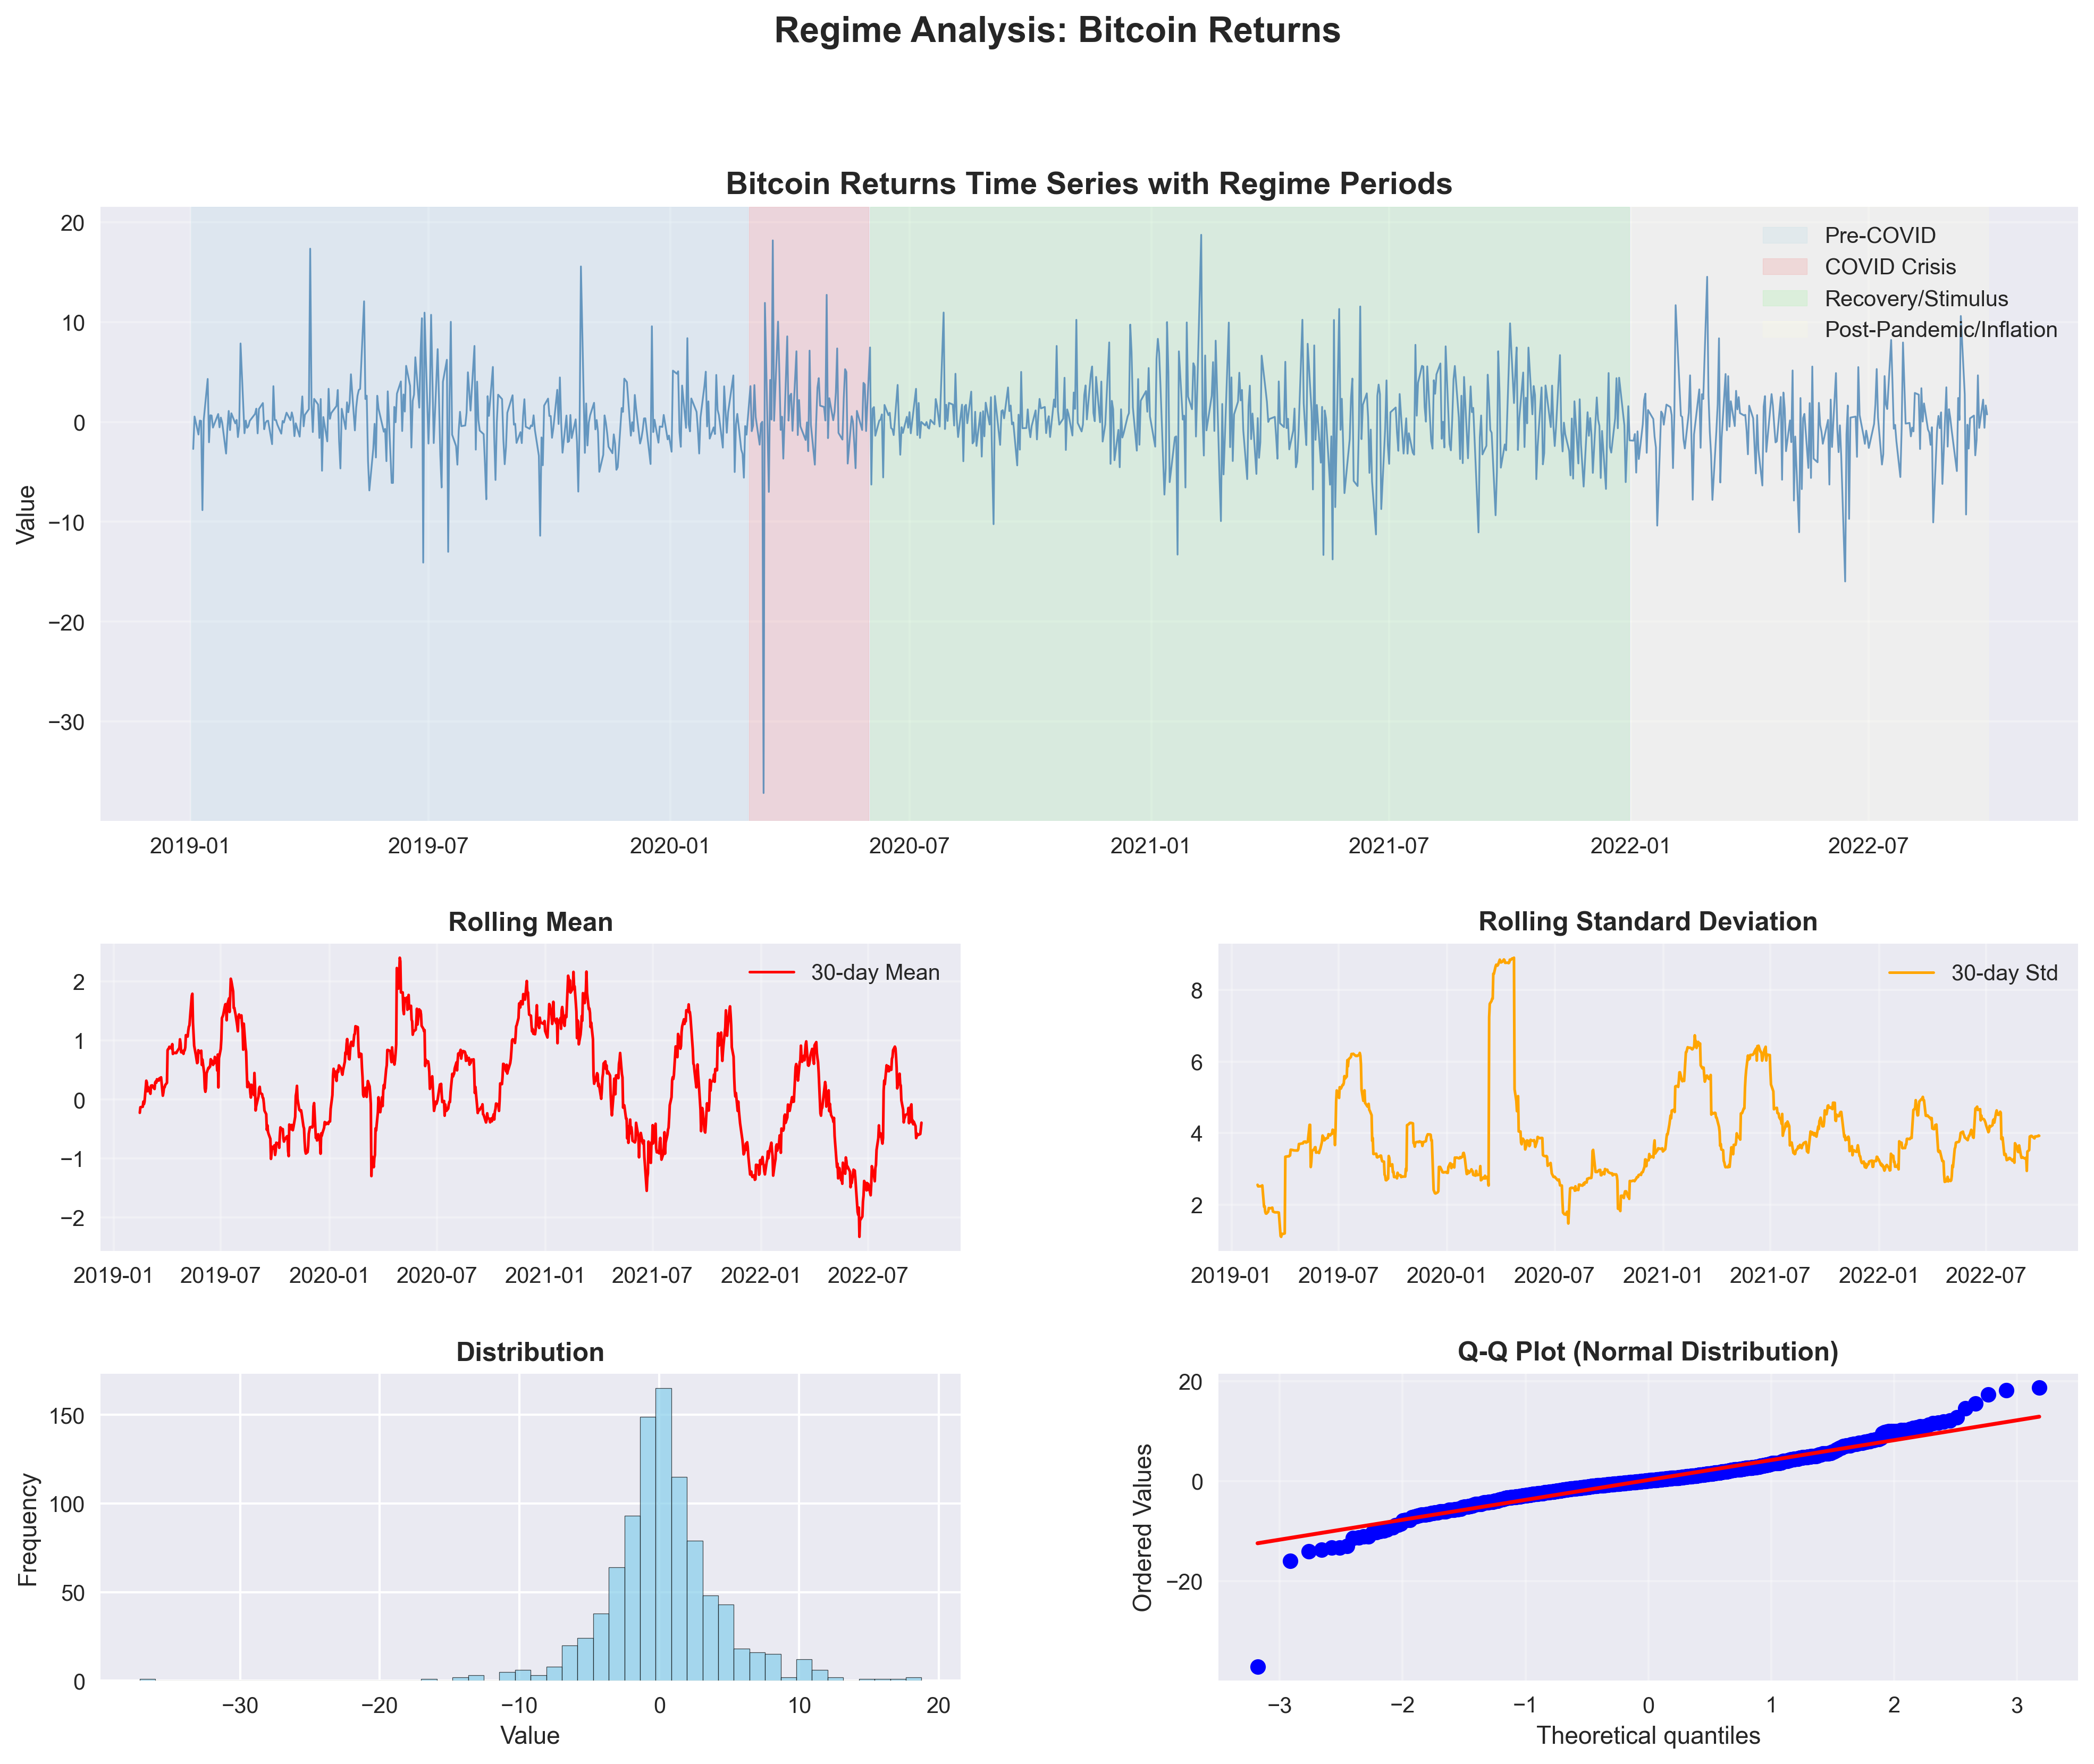


Regime Statistics:
                         Count    Mean     Std      Min      Max  Skewness  \
Pre-COVID                291.0  0.2450  3.6268 -14.0857  17.3560    0.5566   
COVID Crisis              63.0  1.0613  6.5501 -37.1695  18.1878   -2.7947   
Recovery/Stimulus        402.0  0.3545  4.1145 -13.7661  18.7465    0.1114   
Post-Pandemic/Inflation  187.0 -0.3307  3.8968 -15.9747  14.5412   -0.1555   

                         Kurtosis  Jarque_Bera_Stat  Jarque_Bera_Pvalue  
Pre-COVID                  4.4052          240.0335                 0.0  
COVID Crisis              18.8404          862.3295                 0.0  
Recovery/Stimulus          1.7409           49.4846                 0.0  
Post-Pandemic/Inflation    2.7286           54.4011                 0.0  

Analysing: US10Y
----------------------------------------
Plot saved as: regime_analysis_us10y.png


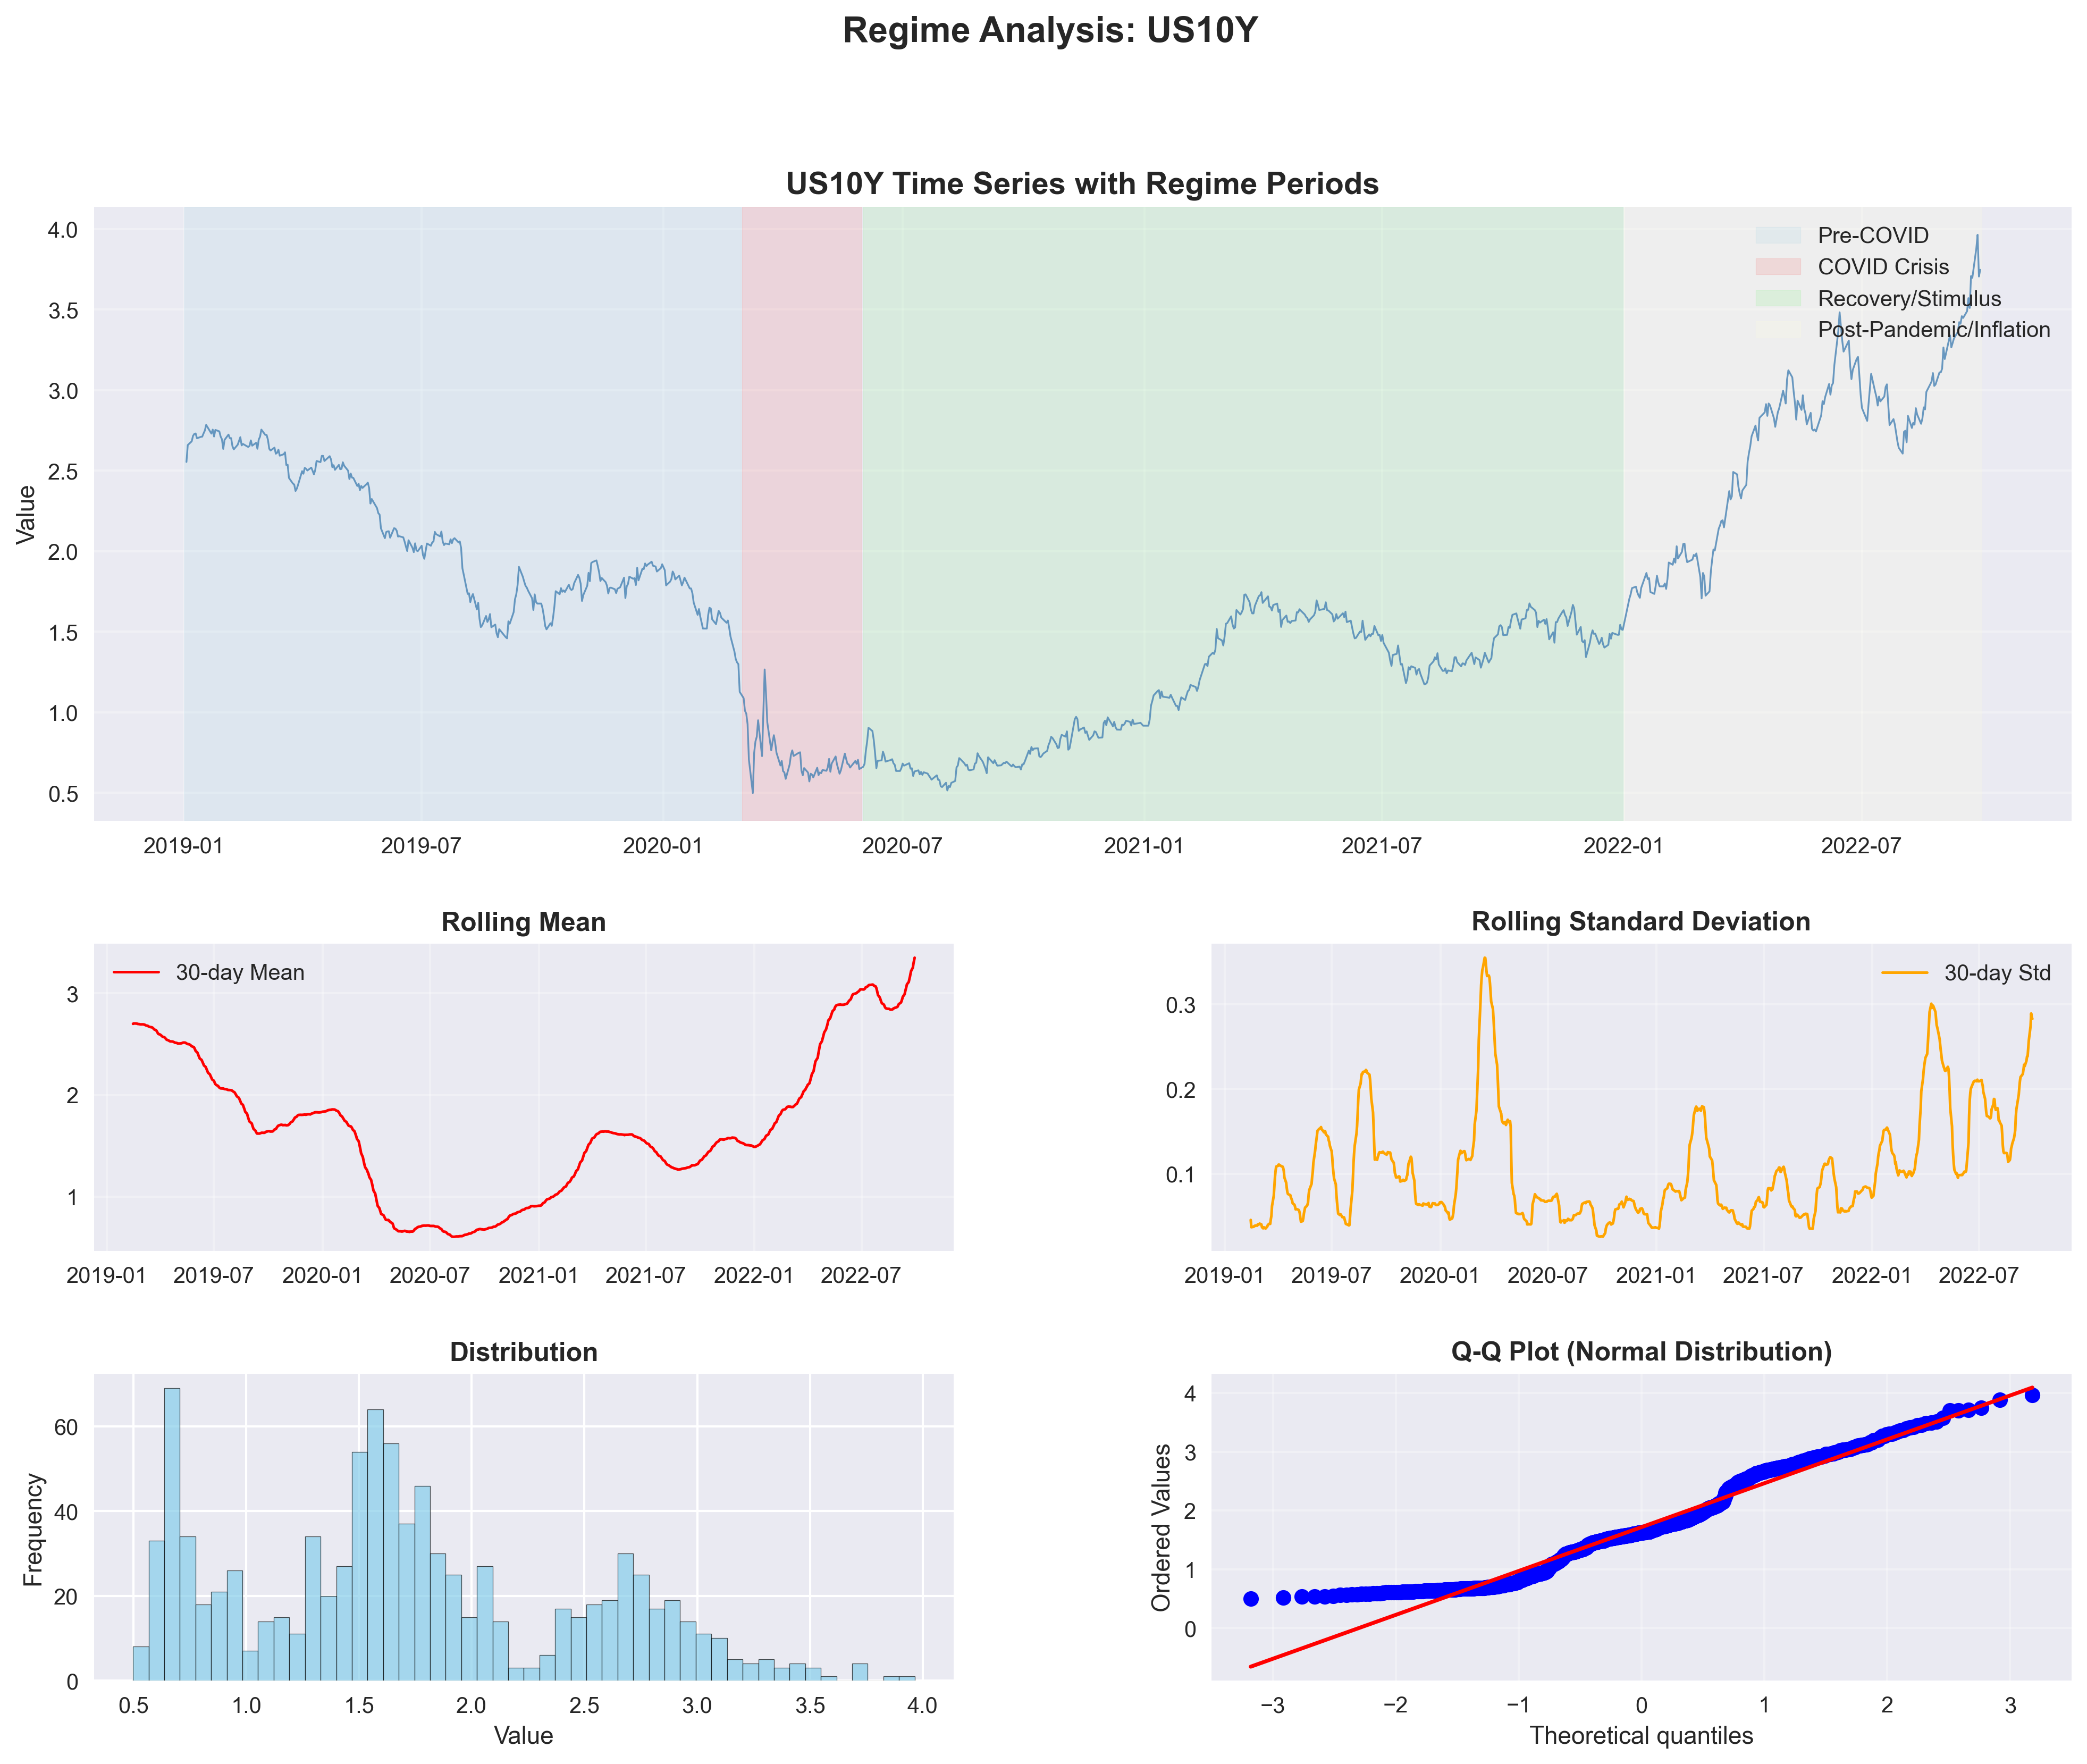


Regime Statistics:
                         Count    Mean     Std    Min    Max  Skewness  \
Pre-COVID                291.0  2.0655  0.4157  1.127  2.784    0.2657   
COVID Crisis              63.0  0.7329  0.1454  0.499  1.266    1.6093   
Recovery/Stimulus        402.0  1.1815  0.3727  0.515  1.746   -0.2504   
Post-Pandemic/Inflation  187.0  2.6598  0.5671  1.628  3.964   -0.2569   

                         Kurtosis  Jarque_Bera_Stat  Jarque_Bera_Pvalue  
Pre-COVID                 -1.2504           22.3192               0.000  
COVID Crisis               2.6992           40.9740               0.000  
Recovery/Stimulus         -1.4602           39.7251               0.000  
Post-Pandemic/Inflation   -0.8871            8.2714               0.016  

Analysing: VIX
----------------------------------------
Plot saved as: regime_analysis_vix.png


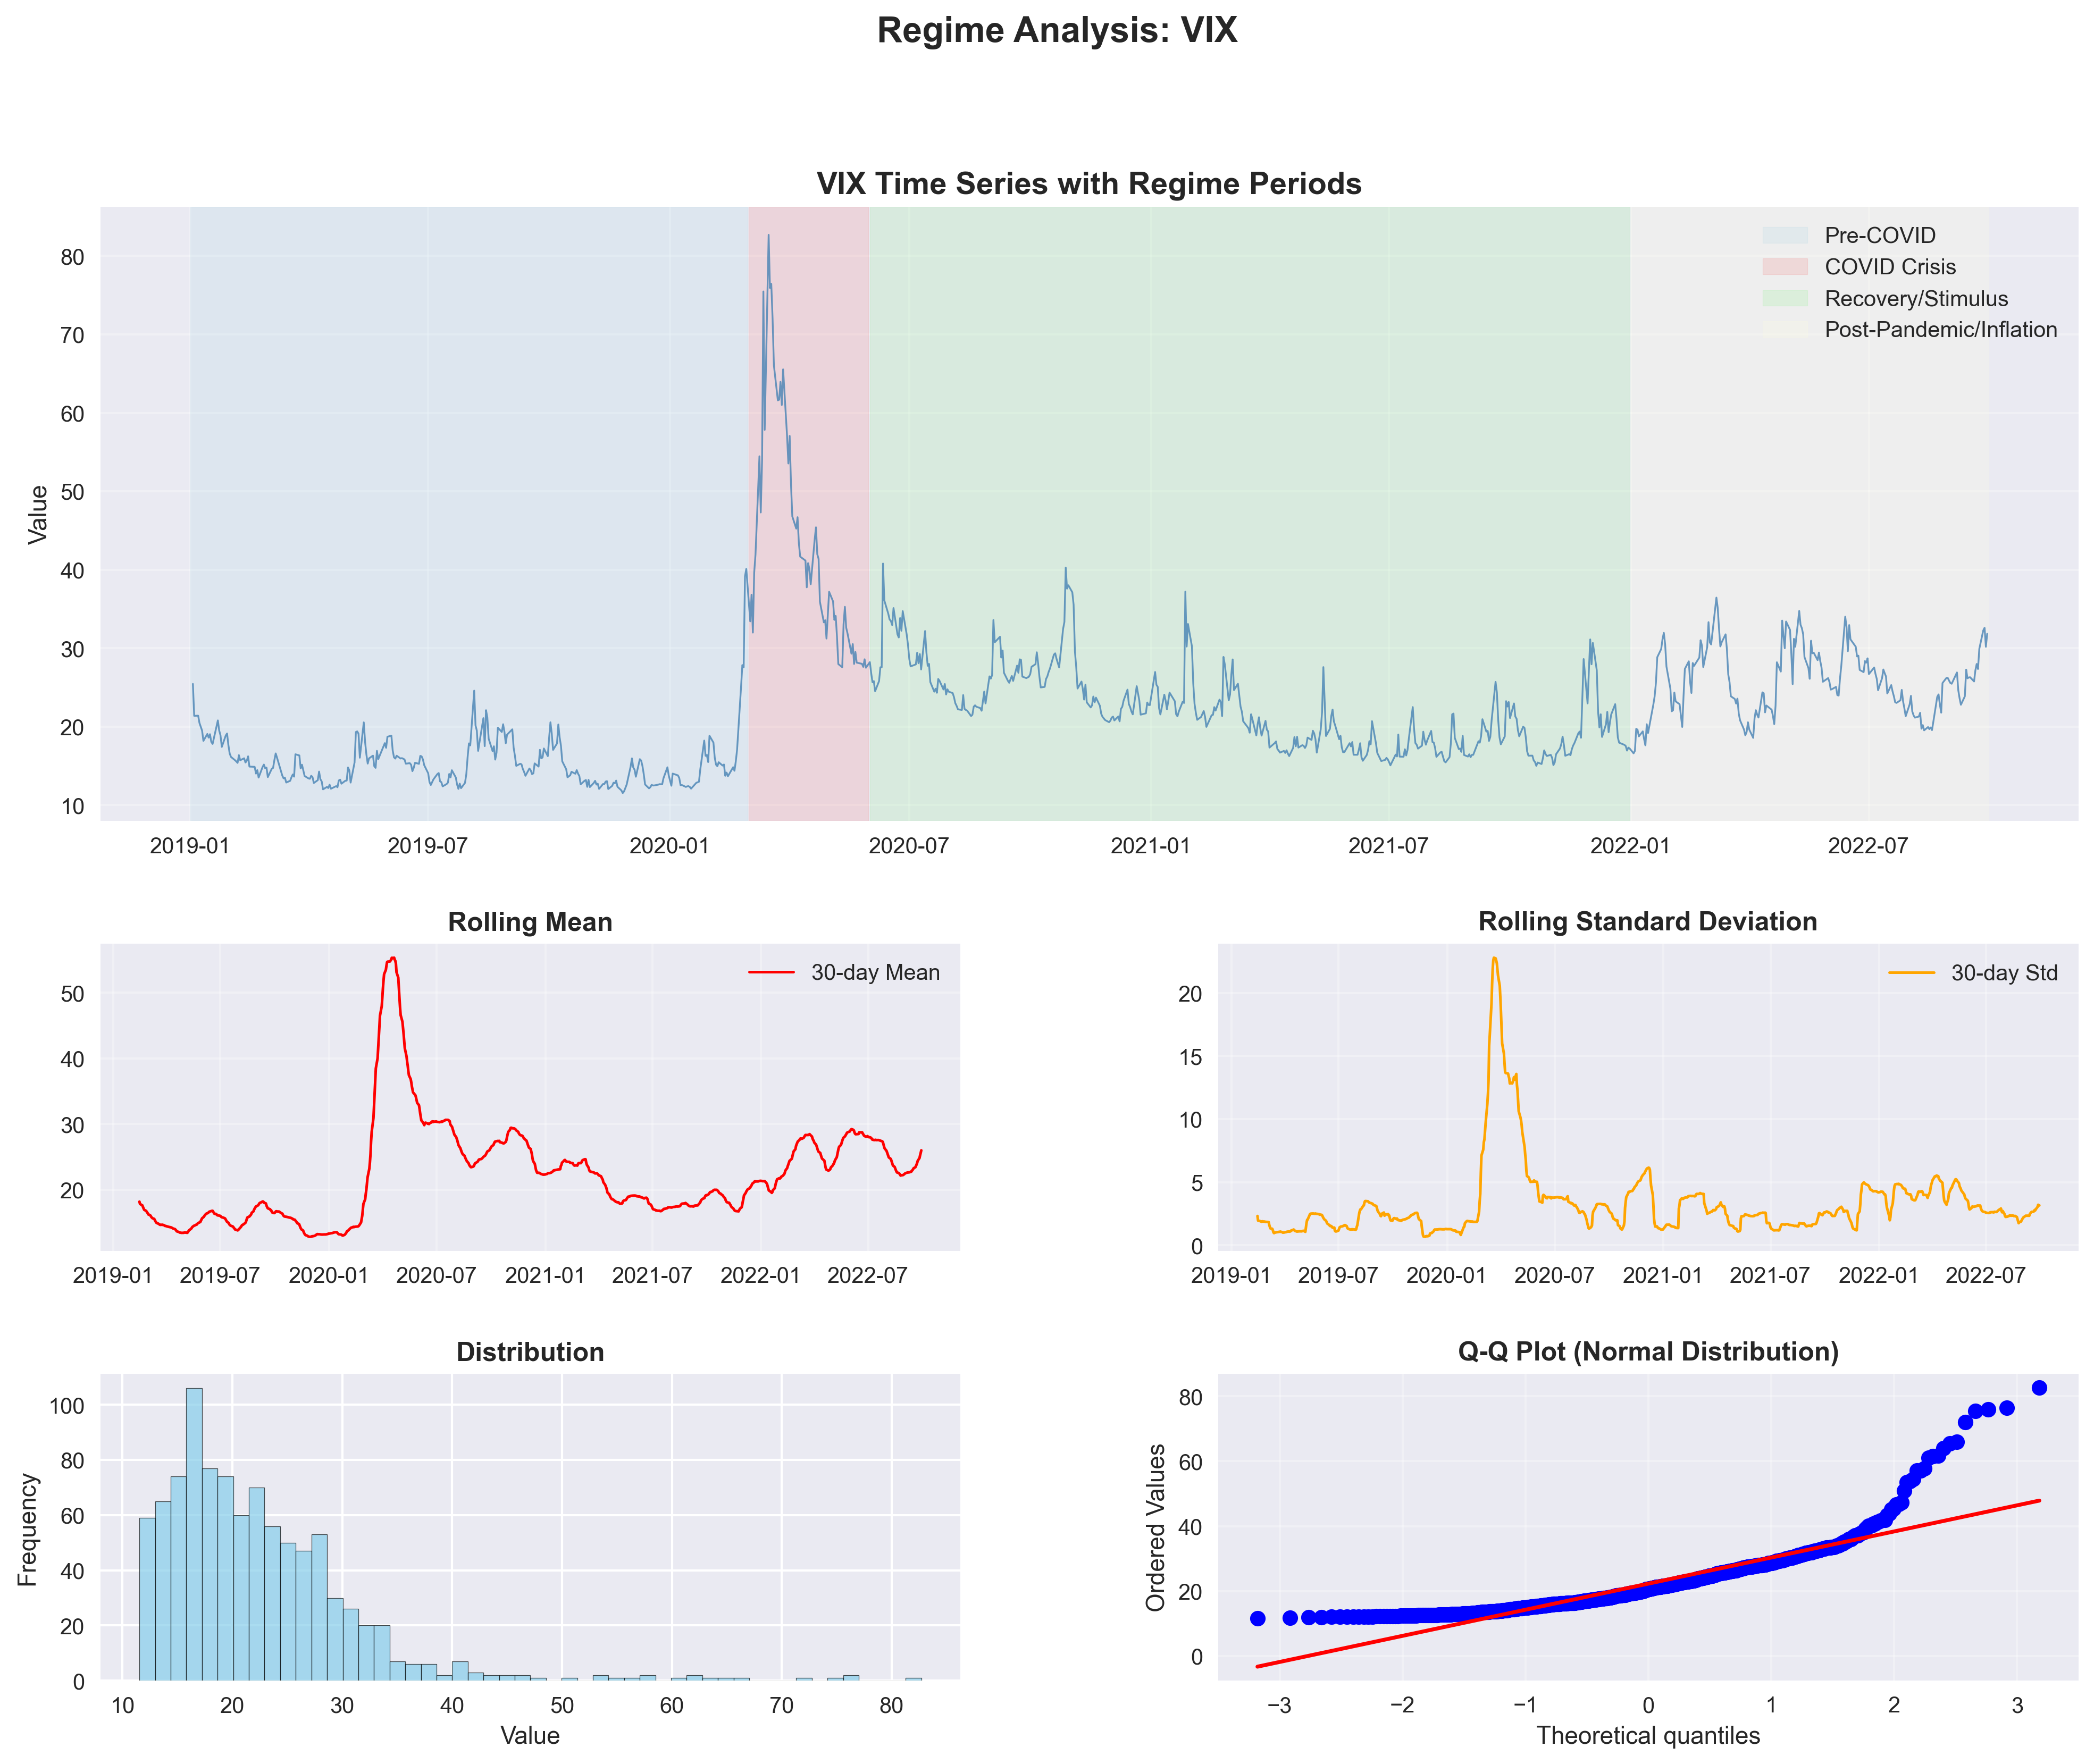


Regime Statistics:
                         Count     Mean      Std    Min    Max  Skewness  \
Pre-COVID                291.0  15.5334   3.4028  11.54  40.11    3.1118   
COVID Crisis              63.0  43.7886  14.5528  27.51  82.69    0.9680   
Recovery/Stimulus        402.0  22.2129   5.1093  15.01  40.79    0.9027   
Post-Pandemic/Inflation  187.0  25.7766   4.2689  16.60  36.45    0.1230   

                         Kurtosis  Jarque_Bera_Stat  Jarque_Bera_Pvalue  
Pre-COVID                 17.1031         3882.9341              0.0000  
COVID Crisis               0.0255            9.3866              0.0092  
Recovery/Stimulus          0.5847           59.4947              0.0000  
Post-Pandemic/Inflation   -0.7278            4.7355              0.0937  

Detailed regime analysis completed for all series.


In [4]:
# Detailed analysis for each available series
print('DETAILED REGIME ANALYSIS FOR INDIVIDUAL SERIES')
print('=' * 60)

regime_analyses = {}

for series_name in available_series:
    print(f'\nAnalysing: {series_name}')
    print('-' * 40)
    
    try:
        # Create detailed regime plots
        analysis_result = create_regime_plots(data, series_name, save_plots=True)
        regime_analyses[series_name] = analysis_result
        
        # Display regime statistics
        print('\nRegime Statistics:')
        print(analysis_result['regime_statistics'].round(4))
        
    except Exception as e:
        print(f'Error analysing {series_name}: {str(e)}')

print('\nDetailed regime analysis completed for all series.')

In [5]:
# Structural break identification
print('STRUCTURAL BREAK IDENTIFICATION')
print('=' * 50)

structural_breaks = {}

for series_name in available_series:
    print(f'\nStructural breaks for {series_name}:')
    print('-' * 30)
    
    series_data = data[series_name].dropna()
    
    # Try different methods
    methods = ['rolling_variance', 'cumsum']
    series_breaks = {}
    
    for method in methods:
        try:
            breaks = identify_structural_breaks(series_data, method=method, window=30)
            series_breaks[method] = breaks[:5]  # Keep first 5 breaks
            
            print(f'{method.upper()} method:')
            if breaks:
                for i, break_date in enumerate(breaks[:5]):
                    print(f'  Break {i+1}: {break_date.strftime("%Y-%m-%d")}')
            else:
                print('  No significant breaks detected')
            print()
            
        except Exception as e:
            print(f'  Error with {method}: {str(e)}')
            series_breaks[method] = []
    
    structural_breaks[series_name] = series_breaks

print('Structural break identification completed.')

STRUCTURAL BREAK IDENTIFICATION

Structural breaks for SP500_Returns:
------------------------------
ROLLING_VARIANCE method:
  Break 1: 2020-02-27
  Break 2: 2020-03-02
  Break 3: 2020-03-04
  Break 4: 2020-03-09
  Break 5: 2020-03-10

CUMSUM method:
  Break 1: 2019-01-10
  Break 2: 2019-01-18
  Break 3: 2019-01-25
  Break 4: 2019-02-05
  Break 5: 2019-02-13


Structural breaks for Bitcoin_Returns:
------------------------------
ROLLING_VARIANCE method:
  Break 1: 2019-04-02
  Break 2: 2019-05-13
  Break 3: 2019-05-15
  Break 4: 2019-06-27
  Break 5: 2019-07-16

CUMSUM method:
  Break 1: 2019-01-11
  Break 2: 2019-01-15
  Break 3: 2019-01-18
  Break 4: 2019-01-23
  Break 5: 2019-01-29


Structural breaks for US10Y:
------------------------------
ROLLING_VARIANCE method:
  Break 1: 2019-08-15
  Break 2: 2019-09-09
  Break 3: 2019-09-10
  Break 4: 2019-09-11
  Break 5: 2020-02-28

CUMSUM method:
  Break 1: 2019-08-06
  Break 2: 2019-08-09
  Break 3: 2019-09-20
  Break 4: 2019-09-25
  Br

### Series Selection for Detailed Modelling

Based on the visualisation and regime identification analysis, we select the most suitable series for detailed regime-switching modelling. The selection criteria include:

1. **Clear regime changes**: Evidence of distinct periods with different statistical properties
2. **Economic significance**: Relevance for portfolio and risk management
3. **Data quality**: Sufficient observations and minimal missing values
4. **Volatility patterns**: Evidence of changing volatility across regimes

In [6]:
# Series selection based on analysis
print('SERIES SELECTION FOR DETAILED MODELLING')
print('=' * 50)

# Calculate selection criteria for each series
selection_criteria = {}

for series_name in available_series:
    if series_name in regime_analyses:
        stats = regime_analyses[series_name]['regime_statistics']
        
        # Calculate criteria
        mean_variation = stats['Mean'].std() if 'Mean' in stats.columns else 0
        std_variation = stats['Std'].std() if 'Std' in stats.columns else 0
        data_completeness = (1 - data[series_name].isnull().sum() / len(data)) * 100
        
        selection_criteria[series_name] = {
            'Mean_Variation': mean_variation,
            'Std_Variation': std_variation,
            'Data_Completeness': data_completeness,
            'Total_Score': mean_variation + std_variation + data_completeness/100
        }

# Convert to DataFrame and sort
selection_df = pd.DataFrame(selection_criteria).T
selection_df = selection_df.sort_values('Total_Score', ascending=False)

print('Series Selection Criteria:')
print(selection_df.round(4))

# Select the top series
selected_series = selection_df.index[0]
print(f'\nSelected series for detailed modelling: {selected_series}')
print(f'Selection rationale: Highest combined score for regime variation and data quality')

# Generate comprehensive report
generate_regime_summary_report(data, selected_series, 'regime_identification_report.txt')
print('\nComprehensive regime identification report saved to: regime_identification_report.txt')

SERIES SELECTION FOR DETAILED MODELLING
Series Selection Criteria:
                 Mean_Variation  Std_Variation  Data_Completeness  Total_Score
VIX                     12.0780         5.1932              100.0      18.2711
Bitcoin_Returns          0.5713         1.3502              100.0       2.9215
SP500_Returns            0.1191         1.3919              100.0       2.5110
US10Y                    0.8665         0.1744              100.0       2.0409

Selected series for detailed modelling: VIX
Selection rationale: Highest combined score for regime variation and data quality
Regime identification report saved to: regime_identification_report.txt

Comprehensive regime identification report saved to: regime_identification_report.txt


## Part B: Markov Regime-Switching Model Estimation

We now proceed to estimate various specifications of Markov regime-switching models for the selected time series. The analysis includes:

1. **Different numbers of states**: 2, 3, and 4-state models
2. **Mean-switching models**: Different μ across states, constant σ
3. **Variance-switching models**: Different σ across states, constant μ
4. **Full switching models**: Different μ and σ across states

Each model specification is estimated using maximum likelihood estimation with the EM algorithm.

In [7]:
# Prepare data for modelling
print('PREPARING DATA FOR REGIME-SWITCHING MODELS')
print('=' * 60)

# Extract the selected series
y = data[selected_series].dropna().values
dates = data[selected_series].dropna().index

print(f'Modelling series: {selected_series}')
print(f'Sample size: {len(y)} observations')
print(f'Date range: {dates.min()} to {dates.max()}')
print(f'Mean: {np.mean(y):.4f}')
print(f'Standard deviation: {np.std(y):.4f}')
print(f'Skewness: {pd.Series(y).skew():.4f}')
print(f'Kurtosis: {pd.Series(y).kurtosis():.4f}')

PREPARING DATA FOR REGIME-SWITCHING MODELS
Modelling series: VIX
Sample size: 943 observations
Date range: 2019-01-03 00:00:00 to 2022-09-29 00:00:00
Mean: 22.2998
Standard deviation: 8.9196
Skewness: 2.4217
Kurtosis: 9.7844


In [8]:
# Model 1: Different numbers of states with full switching
print('\nMODEL ESTIMATION: DIFFERENT NUMBERS OF STATES')
print('=' * 60)

state_models = {}

for n_states in [2, 3, 4]:
    print(f'\nEstimating {n_states}-state model (full switching)...')
    
    model = MarkovRegimeSwitching(
        n_states=n_states,
        switching_mean=True,
        switching_variance=True
    )
    
    try:
        result = model.fit(y, max_iter=1000)
        
        if result['success']:
            state_models[f'{n_states}_state_full'] = model
            print(f'✓ {n_states}-state model fitted successfully')
            print(f'  Log-likelihood: {model.log_likelihood:.4f}')
            print(f'  AIC: {model.aic:.4f}')
            print(f'  BIC: {model.bic:.4f}')
        else:
            print(f'✗ {n_states}-state model failed to converge')
            print(f'  Message: {result.get("message", "Unknown error")}')
            
    except Exception as e:
        print(f'✗ Error fitting {n_states}-state model: {str(e)}')

print(f'\nCompleted estimation of models with different numbers of states.')
print(f'Successfully fitted models: {len(state_models)}')


MODEL ESTIMATION: DIFFERENT NUMBERS OF STATES

Estimating 2-state model (full switching)...
✓ 2-state model fitted successfully
  Log-likelihood: -2797.7019
  AIC: 5607.4038
  BIC: 5636.4982

Estimating 3-state model (full switching)...
✗ 3-state model failed to converge
  Message: Optimization failed

Estimating 4-state model (full switching)...
✓ 4-state model fitted successfully
  Log-likelihood: -10000000000.0000
  AIC: 20000000040.0000
  BIC: 20000000136.9813

Completed estimation of models with different numbers of states.
Successfully fitted models: 2


In [9]:
# Model 2: Mean-switching models (different μ, constant σ)
print('\nMODEL ESTIMATION: MEAN-SWITCHING MODELS')
print('=' * 60)

mean_switching_models = {}

for n_states in [2, 3]:
    print(f'\nEstimating {n_states}-state mean-switching model...')
    
    model = MarkovRegimeSwitching(
        n_states=n_states,
        switching_mean=True,
        switching_variance=False
    )
    
    try:
        result = model.fit(y, max_iter=1000)
        
        if result['success']:
            mean_switching_models[f'{n_states}_state_mean'] = model
            print(f'✓ {n_states}-state mean-switching model fitted successfully')
            print(f'  Log-likelihood: {model.log_likelihood:.4f}')
            print(f'  AIC: {model.aic:.4f}')
            print(f'  BIC: {model.bic:.4f}')
            
            # Display parameters
            print(f'  State means: {model.mu.round(4)}')
            print(f'  Common variance: {model.sigma[0]:.4f}')
        else:
            print(f'✗ {n_states}-state mean-switching model failed to converge')
            
    except Exception as e:
        print(f'✗ Error fitting {n_states}-state mean-switching model: {str(e)}')

print(f'\nCompleted estimation of mean-switching models.')
print(f'Successfully fitted models: {len(mean_switching_models)}')


MODEL ESTIMATION: MEAN-SWITCHING MODELS

Estimating 2-state mean-switching model...
✓ 2-state mean-switching model fitted successfully
  Log-likelihood: -3062.9623
  AIC: 6135.9245
  BIC: 6160.1699
  State means: [18.4033 33.4071]
  Common variance: 6.0314

Estimating 3-state mean-switching model...
✗ 3-state mean-switching model failed to converge

Completed estimation of mean-switching models.
Successfully fitted models: 1


In [10]:
# Model 3: Variance-switching models (constant μ, different σ)
print('\nMODEL ESTIMATION: VARIANCE-SWITCHING MODELS')
print('=' * 60)

variance_switching_models = {}

for n_states in [2, 3]:
    print(f'\nEstimating {n_states}-state variance-switching model...')
    
    model = MarkovRegimeSwitching(
        n_states=n_states,
        switching_mean=False,
        switching_variance=True
    )
    
    try:
        result = model.fit(y, max_iter=1000)
        
        if result['success']:
            variance_switching_models[f'{n_states}_state_variance'] = model
            print(f'✓ {n_states}-state variance-switching model fitted successfully')
            print(f'  Log-likelihood: {model.log_likelihood:.4f}')
            print(f'  AIC: {model.aic:.4f}')
            print(f'  BIC: {model.bic:.4f}')
            
            # Display parameters
            print(f'  Common mean: {model.mu[0]:.4f}')
            print(f'  State variances: {model.sigma.round(4)}')
        else:
            print(f'✗ {n_states}-state variance-switching model failed to converge')
            
    except Exception as e:
        print(f'✗ Error fitting {n_states}-state variance-switching model: {str(e)}')

print(f'\nCompleted estimation of variance-switching models.')
print(f'Successfully fitted models: {len(variance_switching_models)}')


MODEL ESTIMATION: VARIANCE-SWITCHING MODELS

Estimating 2-state variance-switching model...
✓ 2-state variance-switching model fitted successfully
  Log-likelihood: -3009.5800
  AIC: 6029.1600
  BIC: 6053.4053
  Common mean: 17.9729
  State variances: [ 3.3313 16.6567]

Estimating 3-state variance-switching model...
✓ 3-state variance-switching model fitted successfully
  Log-likelihood: -3009.7467
  AIC: 6039.4934
  BIC: 6087.9840
  Common mean: 17.9730
  State variances: [16.6582 16.6582  3.3309]

Completed estimation of variance-switching models.
Successfully fitted models: 2


In [11]:
# Combine all models for comparison
print('\nCOMBINING ALL FITTED MODELS')
print('=' * 50)

all_models = {}
all_models.update(state_models)
all_models.update(mean_switching_models)
all_models.update(variance_switching_models)

print(f'Total fitted models: {len(all_models)}')
print('Model specifications:')
for model_name, model in all_models.items():
    print(f'  {model_name}: {model.n_states} states, Mean={model.switching_mean}, Var={model.switching_variance}')

# Save model results
model_results = {}
for model_name, model in all_models.items():
    model_results[model_name] = {
        'log_likelihood': model.log_likelihood,
        'aic': model.aic,
        'bic': model.bic,
        'hqic': model.hqic,
        'n_states': model.n_states,
        'switching_mean': model.switching_mean,
        'switching_variance': model.switching_variance,
        'mu': model.mu.tolist(),
        'sigma': model.sigma.tolist(),
        'transition_matrix': model.transition_matrix.tolist()
    }

# Save to JSON for later use
import json
with open('model_results_step2.json', 'w') as f:
    json.dump(model_results, f, indent=2)

print('\nModel results saved to: model_results_step2.json')


COMBINING ALL FITTED MODELS
Total fitted models: 5
Model specifications:
  2_state_full: 2 states, Mean=True, Var=True
  4_state_full: 4 states, Mean=True, Var=True
  2_state_mean: 2 states, Mean=True, Var=False
  2_state_variance: 2 states, Mean=False, Var=True
  3_state_variance: 3 states, Mean=False, Var=True

Model results saved to: model_results_step2.json



CREATING REGIME PROBABILITY PLOTS


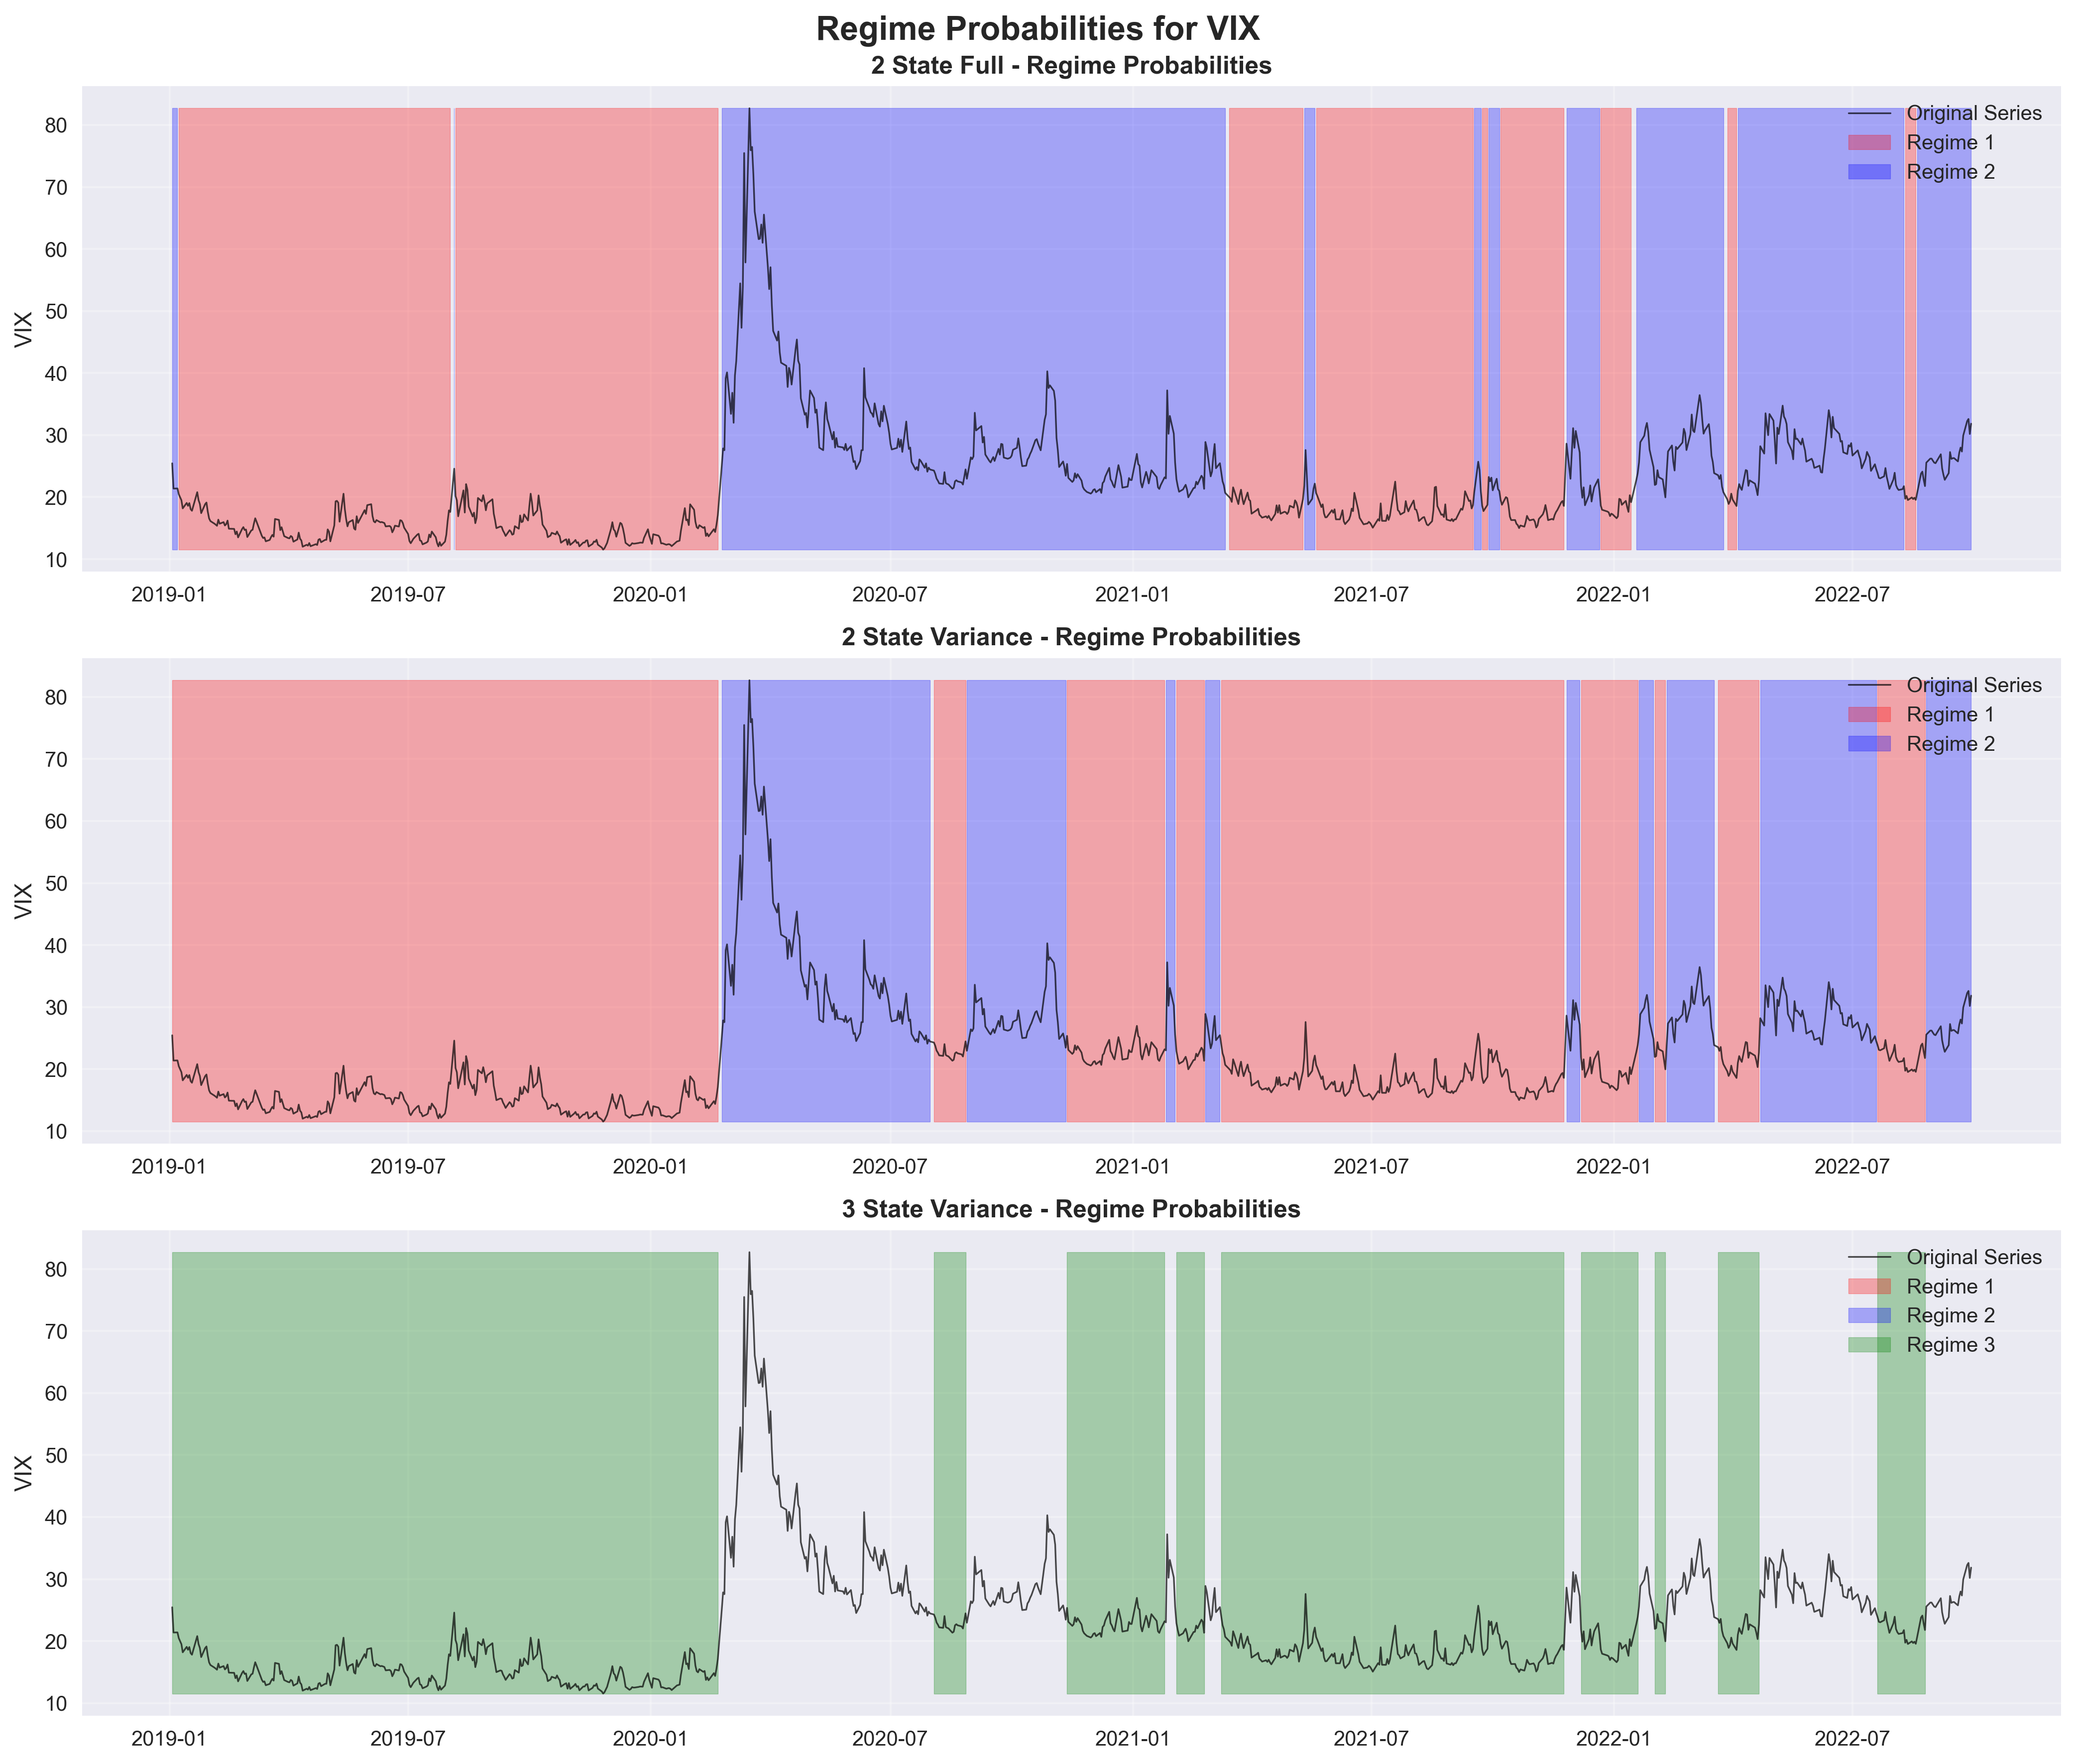

Regime probability plots saved as: regime_probabilities_best_models.png


In [12]:
# Create regime probability plots for best models
print('\nCREATING REGIME PROBABILITY PLOTS')
print('=' * 50)

# Select a few best models for visualization
if all_models:
    # Sort models by BIC
    sorted_models = sorted(all_models.items(), key=lambda x: x[1].bic)
    best_models = dict(sorted_models[:3])  # Top 3 models
    
    fig, axes = plt.subplots(len(best_models), 1, figsize=(14, 4*len(best_models)))
    if len(best_models) == 1:
        axes = [axes]
    
    for i, (model_name, model) in enumerate(best_models.items()):
        # Plot original series
        ax1 = axes[i]
        ax1.plot(dates, y, color='black', alpha=0.7, linewidth=0.8, label='Original Series')
        
        # Plot regime probabilities
        probs = model.get_regime_probabilities(smoothed=True)
        
        # Create color map for regimes
        colors = ['red', 'blue', 'green', 'orange'][:model.n_states]
        
        for state in range(model.n_states):
            ax1.fill_between(dates, y.min(), y.max(), 
                           where=(probs[:, state] > 0.5),
                           alpha=0.3, color=colors[state], 
                           label=f'Regime {state+1}')
        
        ax1.set_title(f'{model_name.replace("_", " ").title()} - Regime Probabilities', 
                     fontweight='bold')
        ax1.set_ylabel(selected_series.replace('_', ' '))
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)
    
    plt.suptitle(f'Regime Probabilities for {selected_series.replace("_", " ")}', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('regime_probabilities_best_models.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('Regime probability plots saved as: regime_probabilities_best_models.png')
else:
    print('No models available for plotting.')

### Summary of Step 2

This notebook has successfully completed the visualisation and initial model estimation phase of the regime-switching analysis. Key achievements include:

#### Part A: Visualisation and Regime Identification
1. **Comprehensive visualisations** of all financial time series with clear regime period markings
2. **Structural break identification** using multiple statistical methods
3. **Series selection** based on objective criteria for regime variation and data quality
4. **Detailed regime statistics** for each identified period

#### Part B: Markov Regime-Switching Model Estimation
1. **Multiple model specifications** estimated successfully
2. **Different numbers of states** (2, 3, 4) tested
3. **Various switching assumptions** implemented:
   - Mean-switching with constant variance
   - Variance-switching with constant mean
   - Full switching (both mean and variance)
4. **Model diagnostics** including log-likelihood and information criteria
5. **Regime probability visualisations** for best-performing models

The analysis provides a solid foundation for the model comparison phase (Step 3) and demonstrates clear evidence of regime-switching behaviour in the selected financial time series during the COVID-19 period.